In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from lmfit import Model
import pathlib as Path
from scipy.signal import savgol_filter
from sklearn.preprocessing import OneHotEncoder

import src.modeling as mod
import src.preprocessing as pre

In [54]:
from pathlib import Path
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_25_lowess_timeseries.csv')
df = pd.read_csv(x)
df

,condition,id,category,valence,time,LDX (pix),LDY (pix),RDX (pix),RDY (pix),LDX_lowess,LDY_lowess,RDX_lowess,RDY_lowess
0,ACP,ACP_10,objet,negative,0.000000,0.041475,12.574262,-0.767978,9.236503,1.983911,12.603723,3.450543,8.745252
1,ACP,ACP_10,objet,negative,1.000558,0.241475,11.974262,-1.567978,6.436503,1.991126,12.606841,3.403829,8.724673
2,ACP,ACP_10,objet,negative,2.001117,-0.158525,5.374262,-1.367978,5.436503,1.997769,12.609701,3.356562,8.703663
3,ACP,ACP_10,objet,negative,3.001675,0.041475,10.374262,0.032022,7.636503,2.003828,12.612299,3.308732,8.682214
4,ACP,ACP_10,objet,negative,4.002233,-0.558525,12.174262,0.032022,7.036503,2.009291,12.614634,3.260330,8.660316
...,...,...,...,...,...,...,...,...,...,...,...,...,...
924667,DFT,DFT_9,visage,positive,1787.997767,-31.112508,-20.429326,-23.756709,-26.483485,-32.867712,-25.156976,-28.077767,-28.674864
924668,DFT,DFT_9,visage,positive,1788.998325,-29.512508,-19.229326,-24.356709,-23.483485,-32.977027,-25.256431,-28.172568,-28.780666
924669,DFT,DFT_9,visage,positive,1789.998883,-30.312508,-22.029326,-25.156709,-23.483485,-33.085890,-25.355475,-28.267085,-28.886203
924670,DFT,DFT_9,visage,positive,1790.999442,-30.512508,-21.029326,-26.156709,-26.283485,-33.194305,-25.454111,-28.361319,-28.991475


In [3]:
df['RDX_rolling'] = df.groupby(['condition_id', 'category', 'valence'])['RDX (pix)'].transform(
    lambda x: x.rolling(window=20, min_periods=1).mean()
)

latence au minimum, latence au maximum, pente de dilatation (2–4 s)

In [58]:
df['RDX_min'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: x.iloc[0] - x.iloc[:500].min()
)

df['RDX_lat_min'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: x.iloc[:500].argmin() + 50 if x.notna().any() else None
)

df['RDX_max'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: x.iloc[400:1750].max() - x.iloc[:500].min()
)

df['RDX_lat_max'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: x.iloc[400:1750].argmax() + 400 if x.notna().any() else None
)

df['RDX_max_con_velocity'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: np.gradient(x.iloc[:500]).min()
)

df['RDX_ave_con_velocity'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: np.gradient(x.iloc[:500]).mean()
)

df['RDX_max_dil_velocity'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: np.gradient(x.iloc[x.iloc[:500].argmin():x.iloc[500:1750].argmax() + 400]).min()
)

df['RDX_ave_dil_velocity'] = df.groupby(['id', 'category', 'valence'])['RDX_lowess'].transform(
    lambda x: np.gradient(x.iloc[x.iloc[:500].argmin():x.iloc[500:1750].argmax() + 400]).mean()
)




# df['RDY_min'] = df.groupby(['id', 'category', 'valence'])['RDY_lowess'].transform(
#     lambda x: x.iloc[50:500].min()
# )

# df['RDY_lat_min'] = df.groupby(['id', 'category', 'valence'])['RDY_lowess'].transform(
#     lambda x: x.iloc[50:500].argmin() + 50 if x.notna().any() else None
# )

# df['RDY_max'] = df.groupby(['id', 'category', 'valence'])['RDY_lowess'].transform(
#     lambda x: x.iloc[400:1750].max()
# )

# df['RDY_lat_max'] = df.groupby(['id', 'category', 'valence'])['RDY_lowess'].transform(
#     lambda x: x.iloc[400:1750].argmax() + 400 if x.notna().any() else None
# )

# # gradient of curve between 2 and 4 seconds
# df['RDX_grad'] = df.groupby(['condition_id', 'category', 'valence'])['RDX_rolling'].transform(
#     lambda x: (x.iloc[1200]-x.iloc[300])/900 if x.notna().any() else None
# )


# df['RDY_grad'] = (df.RDY_max - df.RDY_min)/(df.RDY_lat_max - df.RDY_lat_min)

# df['RDX_area_min'] = df.RDX_min * df.RDY_min * np.pi
# df['RDX_area_max'] = df.RDX_max * df.RDY_max * np.pi

In [63]:
df

,condition,id,category,valence,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_max_con_velocity,RDX_ave_con_velocity,RDX_max_dil_velocity,RDX_ave_dil_velocity
0,ACP,ACP_10,objet,negative,44.127602,346,33.454115,1590,-0.338707,-0.061801,-0.289442,0.018440
1792,ACP,ACP_10,objet,neutre,71.281200,407,69.731651,541,-0.371115,-0.020149,0.006690,0.336721
3584,ACP,ACP_10,objet,positive,82.133854,352,41.032451,1685,-0.402958,-0.130841,-0.079394,0.025909
5376,ACP,ACP_10,visage,negative,88.524097,363,63.232905,1749,-0.420667,-0.140457,-0.119972,0.039628
7168,ACP,ACP_10,visage,neutre,56.626798,307,36.890171,1203,-0.413003,-0.067720,-0.093488,0.036191
...,...,...,...,...,...,...,...,...,...,...,...,...
915712,DFT,DFT_9,objet,neutre,27.136757,338,28.277840,1585,-0.181159,-0.052481,-0.189637,0.016022
917504,DFT,DFT_9,objet,positive,29.964145,330,35.903224,1285,-0.338898,-0.031363,-0.104744,0.025830
919296,DFT,DFT_9,visage,negative,43.566890,324,42.014266,1702,-0.291433,-0.071399,-0.149004,0.027545
921088,DFT,DFT_9,visage,neutre,35.302605,377,36.768773,1624,-0.236194,-0.048923,-0.087579,0.024589


In [64]:
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
ohetransform = ohe.fit_transform(df[['category', 'valence']])
df = pd.concat([df, ohetransform], axis=1)
df

,condition,id,category,valence,RDX_min,RDX_lat_min,RDX_max,RDX_lat_max,RDX_max_con_velocity,RDX_ave_con_velocity,RDX_max_dil_velocity,RDX_ave_dil_velocity,category_objet,category_visage,valence_negative,valence_neutre,valence_positive
0,ACP,ACP_10,objet,negative,44.127602,346,33.454115,1590,-0.338707,-0.061801,-0.289442,0.018440,1.0,0.0,1.0,0.0,0.0
1792,ACP,ACP_10,objet,neutre,71.281200,407,69.731651,541,-0.371115,-0.020149,0.006690,0.336721,1.0,0.0,0.0,1.0,0.0
3584,ACP,ACP_10,objet,positive,82.133854,352,41.032451,1685,-0.402958,-0.130841,-0.079394,0.025909,1.0,0.0,0.0,0.0,1.0
5376,ACP,ACP_10,visage,negative,88.524097,363,63.232905,1749,-0.420667,-0.140457,-0.119972,0.039628,0.0,1.0,1.0,0.0,0.0
7168,ACP,ACP_10,visage,neutre,56.626798,307,36.890171,1203,-0.413003,-0.067720,-0.093488,0.036191,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915712,DFT,DFT_9,objet,neutre,27.136757,338,28.277840,1585,-0.181159,-0.052481,-0.189637,0.016022,1.0,0.0,0.0,1.0,0.0
917504,DFT,DFT_9,objet,positive,29.964145,330,35.903224,1285,-0.338898,-0.031363,-0.104744,0.025830,1.0,0.0,0.0,0.0,1.0
919296,DFT,DFT_9,visage,negative,43.566890,324,42.014266,1702,-0.291433,-0.071399,-0.149004,0.027545,0.0,1.0,1.0,0.0,0.0
921088,DFT,DFT_9,visage,neutre,35.302605,377,36.768773,1624,-0.236194,-0.048923,-0.087579,0.024589,0.0,1.0,0.0,1.0,0.0


In [5]:
df[::1792].drop(columns=['category', 'valence', 'time', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)', 'LDX_lowess','LDY_lowess', 'RDX_lowess', 'RDY_lowess']).to_csv('2026_09_28_lowess_trainingset_2.csv', index=False)

In [6]:
df = pre.one_hot_encoder(df).drop(columns=['time', 'LDX (pix)', 'LDY (pix)', 'RDX (pix)', 'RDY (pix)', 'LDX_lowess', 'LDY_lowess', 'RDX_lowess', 'RDY_lowess', 'category', 'valence'])

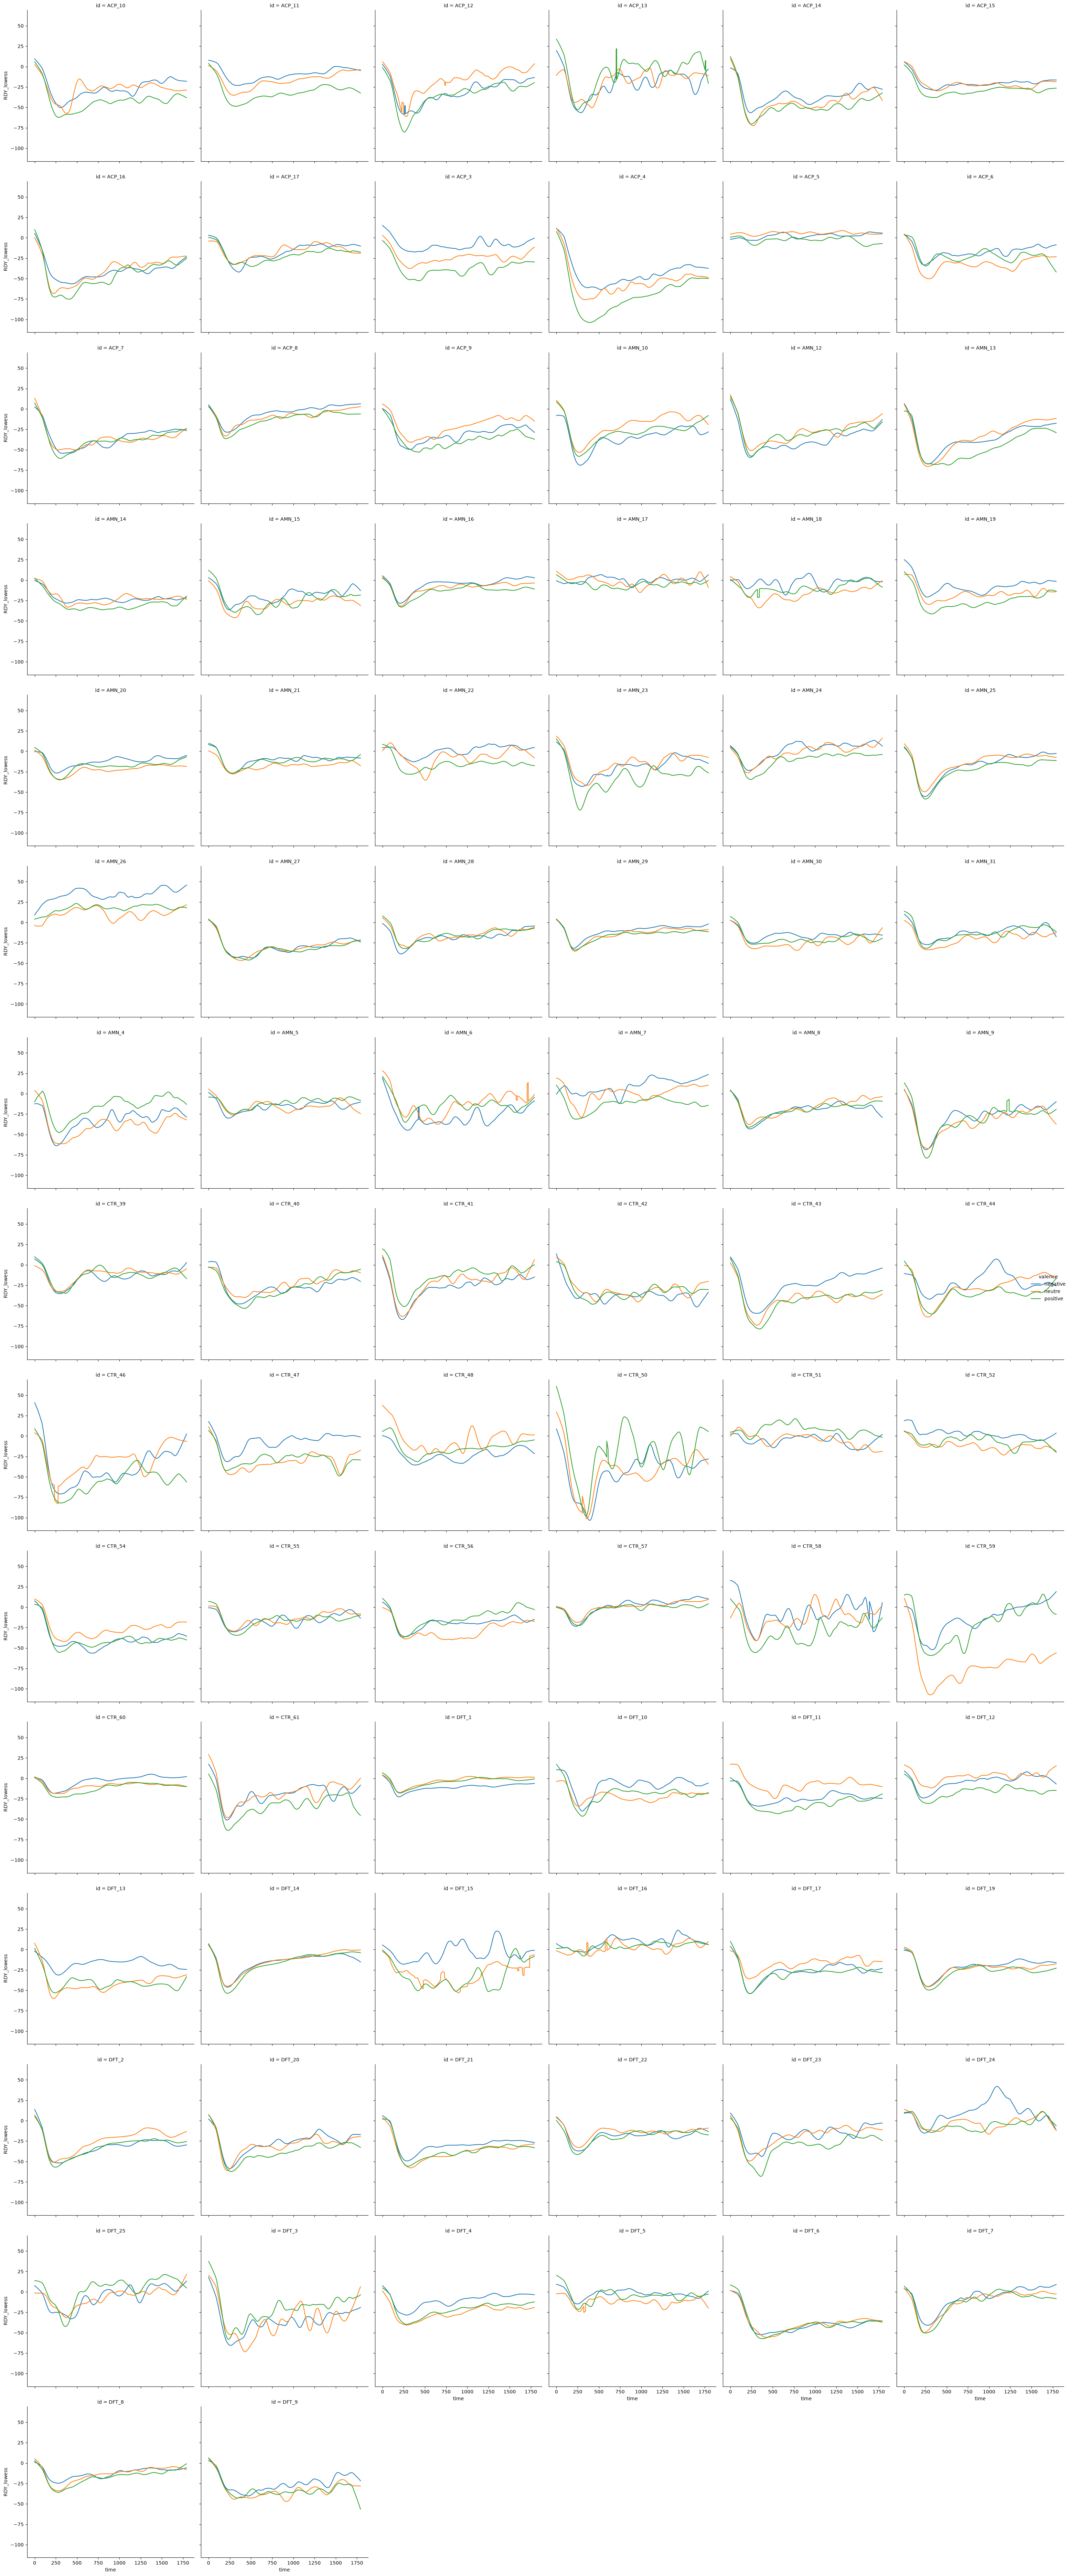

In [3]:
sns.relplot(df, x='time', y='RDY_lowess', hue='valence', col='id', col_wrap=6, kind='line', errorbar=None)
plt.tight_layout()